# Copper wire production line analysis

In [104]:
import pandas as pd

In [105]:
data = pd.read_csv('./CourseProject/Cable-Production-Line-Dataset.csv')

In [106]:
data.keys()

Index(['Machine', 'Shift', 'Operator', 'Date', 'Cable Failures',
       'Cable Failure Downtime', 'Other Failures', 'Other Failure Downtime'],
      dtype='object')

In [107]:
data.head()

,Machine,Shift,Operator,Date,Cable Failures,Cable Failure Downtime,Other Failures,Other Failure Downtime
0,1,A,1,11/6/2020,1,35,1,30
1,2,A,2,11/6/2020,1,10,3,150
2,2,B,3,11/6/2020,2,40,2,110
3,2,A,2,11/7/2020,5,120,1,80
4,2,B,3,11/7/2020,2,40,1,35


In [108]:
data['Shift'].unique()

array(['A', 'B'], dtype=object)

In [28]:
data['Shift'] = data['Shift'].replace({'A': 0, 'B': 1})

C:\Users\Nikit\AppData\Local\Temp\ipykernel_6024\2492628578.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['Shift'] = data['Shift'].replace({'A': 0, 'B': 1})


In [29]:
data['Total Failures'] = data['Cable Failures'] + data['Other Failures']
data['Total Downtime'] = data['Cable Failure Downtime'] + data['Other Failure Downtime']

data['Date'] = pd.to_datetime(data['Date'])
data.sort_values(by='Date')

data.head()

,Machine,Shift,Operator,Date,Cable Failures,Cable Failure Downtime,Other Failures,Other Failure Downtime,Total Failures,Total Downtime
0,1,0,1,2020-11-06,1,35,1,30,2,65
1,2,0,2,2020-11-06,1,10,3,150,4,160
2,2,1,3,2020-11-06,2,40,2,110,4,150
3,2,0,2,2020-11-07,5,120,1,80,6,200
4,2,1,3,2020-11-07,2,40,1,35,3,75


In [33]:
data.describe()

,Machine,Shift,Operator,Date,Cable Failures,Cable Failure Downtime,Other Failures,Other Failure Downtime,Total Failures,Total Downtime
count,149.000000,149.000000,149.000000,149,149.000000,149.000000,149.000000,149.00000,149.000000,149.000000
mean,5.932886,0.489933,12.946309,2020-11-15 12:14:29.798657792,1.409396,51.442953,0.536913,47.04698,1.946309,98.489933
min,1.000000,0.000000,1.000000,2020-11-06 00:00:00,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,2.000000,0.000000,6.000000,2020-11-12 00:00:00,0.000000,0.000000,0.000000,0.00000,1.000000,30.000000
50%,5.000000,0.000000,12.000000,2020-11-15 00:00:00,1.000000,35.000000,0.000000,0.00000,1.000000,60.000000
75%,8.000000,1.000000,18.000000,2020-11-19 00:00:00,2.000000,70.000000,1.000000,45.00000,2.000000,120.000000
max,17.000000,1.000000,32.000000,2020-11-22 00:00:00,6.000000,295.000000,9.000000,690.00000,9.000000,690.000000
std,4.294346,0.501585,8.659306,NaN,1.325495,56.658935,0.969281,106.39678,1.417960,112.009750


In [112]:
data['Operator'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32])

In [113]:
data['Machine'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17])

<Axes: xlabel='Date'>

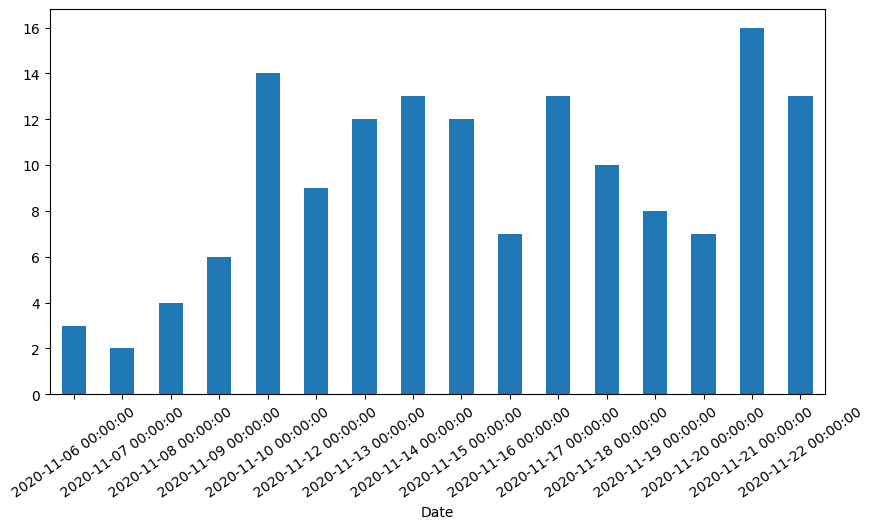

In [114]:
data['Date'].value_counts().sort_index().plot.bar(figsize=(10,5), rot=35)

<Axes: xlabel='Date'>

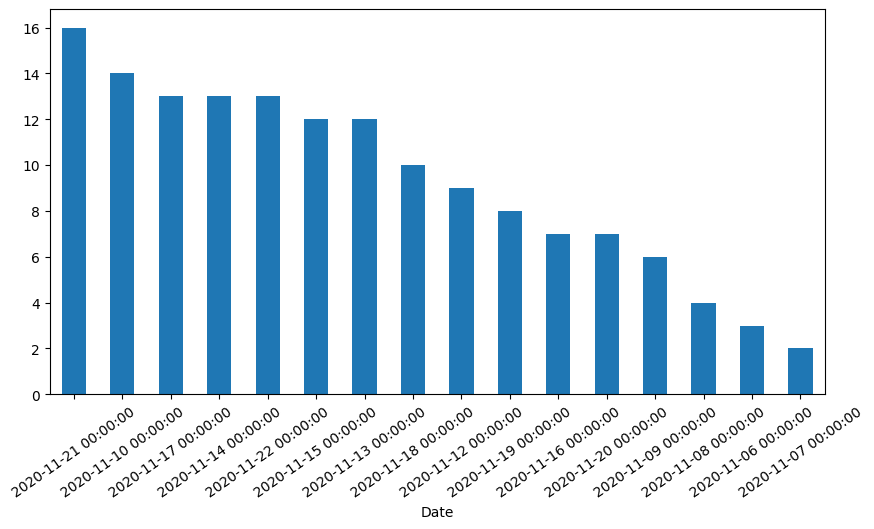

In [115]:
data['Date'].value_counts().plot.bar(figsize=(10,5), rot=35)

<Axes: xlabel='Machine', ylabel='Minutes'>

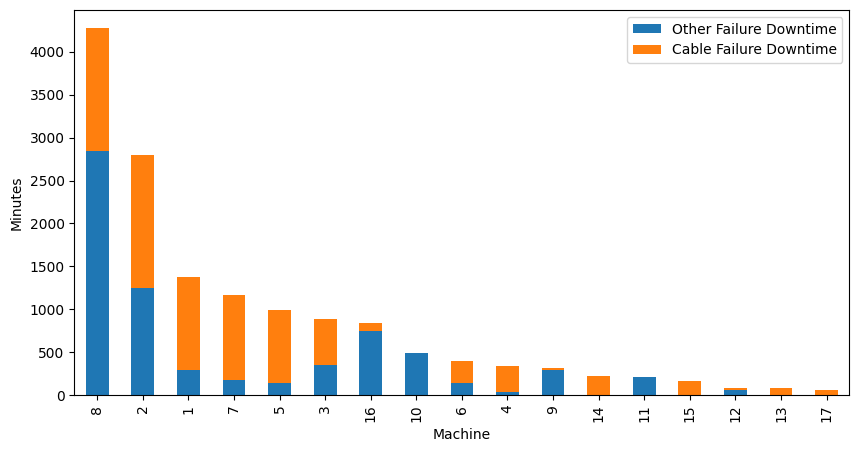

In [116]:
grouped = data.groupby('Machine')[['Other Failure Downtime','Cable Failure Downtime', 'Total Downtime']].sum().sort_values(by='Total Downtime', ascending=False)
grouped.drop(columns='Total Downtime', inplace=True)
grouped.plot.bar(stacked=True, xlabel='Machine', ylabel='Minutes', figsize=(10,5))

<Axes: xlabel='Machine', ylabel='Frequency'>

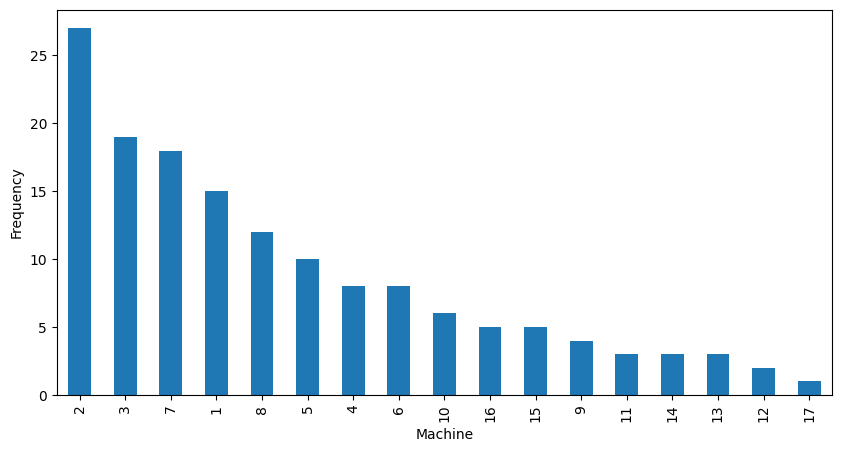

In [117]:
data['Machine'].value_counts().plot.bar(figsize=(10,5), ylabel='Frequency')

<Axes: xlabel='Operator', ylabel='Frequency'>

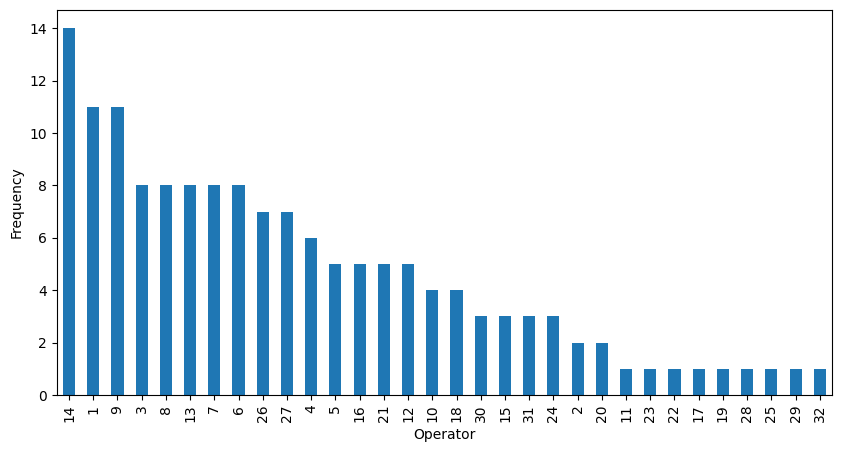

In [21]:
data['Operator'].value_counts().plot.bar(figsize=(10,5), ylabel='Frequency')

In [22]:
data['Cable Failures'].sum()

np.int64(210)

In [23]:
data['Cable Failure Downtime'].sum()

np.int64(7665)

In [24]:
data['Other Failures'].sum()

np.int64(80)

In [25]:
data['Other Failure Downtime'].sum()

np.int64(7010)

In [37]:
corr_matrix = data.corr()
corr_matrix

,Machine,Shift,Operator,Date,Cable Failures,Cable Failure Downtime,Other Failures,Other Failure Downtime,Total Failures,Total Downtime
Machine,1.000000,0.031053,0.697636,0.175588,-0.202871,-0.132617,0.088256,0.153655,-0.129313,0.078873
Shift,0.031053,1.000000,0.100992,-0.012885,-0.130958,-0.058329,0.038988,0.026027,-0.095767,-0.004782
Operator,0.697636,0.100992,1.000000,0.249564,-0.089906,-0.005419,0.105695,0.135611,-0.011792,0.126075
Date,0.175588,-0.012885,0.249564,1.000000,-0.002434,0.031388,-0.045352,0.086841,-0.033277,0.098366
Cable Failures,-0.202871,-0.130958,-0.089906,-0.002434,1.000000,0.757265,-0.266907,-0.222059,0.752339,0.172123
Cable Failure Downtime,-0.132617,-0.058329,-0.005419,0.031388,0.757265,1.000000,-0.246734,-0.164583,0.539223,0.349503
Other Failures,0.088256,0.038988,0.105695,-0.045352,-0.266907,-0.246734,1.000000,0.440034,0.434072,0.293176
Other Failure Downtime,0.153655,0.026027,0.135611,0.086841,-0.222059,-0.164583,0.440034,1.000000,0.093217,0.866636
Total Failures,-0.129313,-0.095767,-0.011792,-0.033277,0.752339,0.539223,0.434072,0.093217,1.000000,0.361306
Total Downtime,0.078873,-0.004782,0.126075,0.098366,0.172123,0.349503,0.293176,0.866636,0.361306,1.000000


<Axes: >

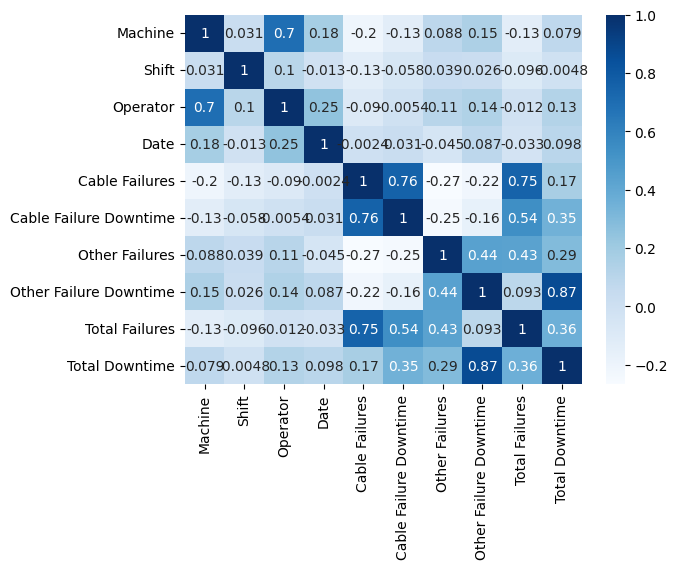

In [54]:
import seaborn as sns
sns.heatmap(corr_matrix, cmap='Blues', annot=True)

<Axes: ylabel='Cable Failure Downtime by Machine'>

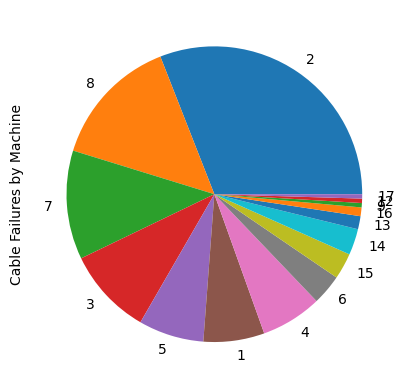

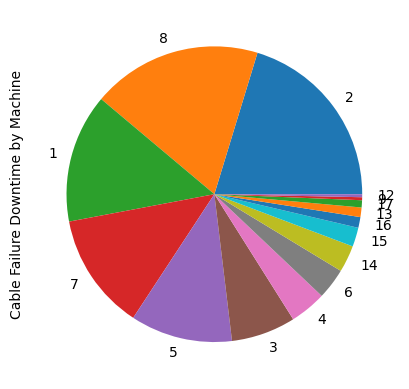

In [95]:
grouped = data.groupby(by='Machine')[['Cable Failures', 'Cable Failure Downtime']].sum()
grouped.sort_values(by='Cable Failures', ascending=False).plot.pie(y='Cable Failures', legend=False, label='Cable Failures by Machine')
grouped.sort_values(by='Cable Failure Downtime', ascending=False).plot.pie(y='Cable Failure Downtime', legend=False, label='Cable Failure Downtime by Machine')

In [96]:
grouped.sort_values(by='Cable Failure Downtime', ascending=False)['Cable Failure Downtime'][0:4].sum()/data['Cable Failure Downtime'].sum()*100

np.float64(65.75342465753424)

<Axes: ylabel='Cable Failure Downtime by Operator'>

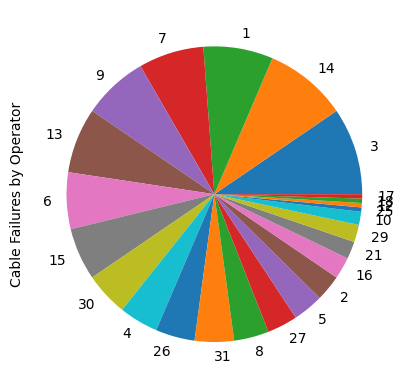

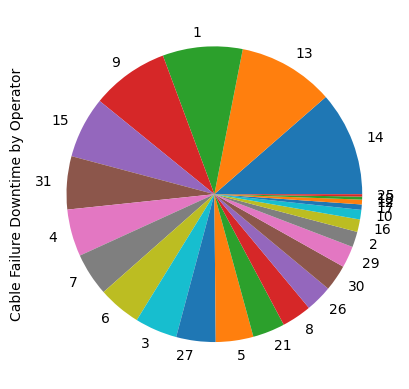

In [97]:
grouped = data.groupby(by='Operator')[['Cable Failures', 'Cable Failure Downtime']].sum()
grouped.sort_values(by='Cable Failures', ascending=False).plot.pie(y='Cable Failures', legend=False, label='Cable Failures by Operator')
grouped.sort_values(by='Cable Failure Downtime', ascending=False).plot.pie(y='Cable Failure Downtime', legend=False, label='Cable Failure Downtime by Operator')

In [98]:
grouped.sort_values(by='Cable Failure Downtime', ascending=False)['Cable Failure Downtime'][0:4].sum()/data['Cable Failure Downtime'].sum()*100

np.float64(39.138943248532286)